# 1. Espacios de Probabilidad

## 1.1 Probabilidad Clásica 

### Un espacio de probabilidad se encuentra caracterizado por tres componentes: $(\Omega, \mathcal{F}, \mathbb{P})$. $\Omega$ representa el espacio muestral, el cual esta conformado por los posibles resultados de un experimento aleatorio. La siguiente componente es el espacio de eventos $\mathcal{F}$, el cual es un subconjunto de $\mathcal{Pot}(\Omega)$. Finalmente, $\mathbb{P}:\mathcal{F}\rightarrow [0,1]$ es la medida de probabilidad. 

### De aquí existen tres enfoques para abordar la medida de probabilidad en función de la cardinalidad del espacio muestral $\Omega$. Iniciemos con el caso finito, para este caso se considera la medida de probabilidad dada por:\begin{align} \mathbb{P}(A)=\frac{\mathcal{Card}(A)}{\mathcal{Card}(\Omega}), A\in \mathcal{F}.\end{align} 

### Ejemplo 1.1.1: Lanzamiento de dos dados

### Consideremos el experimento aleatorio de lanzar dos dados. En este caso el espacio muestral esta dado por \begin{align} \Omega=\{(i,j):i, j\in \{1,2,..., 6\}\}.\end{align} El espacio de eventos es $\mathcal{F}=\mathcal{Pot}(\Omega)$. 

<a href="https://docs.python.org/3/library/itertools.html" target="black">Itertools</a>

In [4]:
from itertools import product
Omega=list(product({1,2,3,4,5,6}, repeat=2))
print(Omega)

[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


### Consideremos el siguiente evento: \begin{align} E_n=\{(i,j)\in \Omega: i+j=n\}, \end{align} con $n\in \{2,..., 12\}$.

### Calcular la probabilidad de que al lanzar dos dados obtengamos un 5: \begin{align} \mathbb{P}(E_5)=\frac{\mathcal{Card}(E_5)}{\mathcal{Card}(\Omega)}\end{align}

In [2]:
def E(n):
    En = {(i,j) for (i,j) in Omega if i+j==n}
    return En

In [5]:
print(f'la probaliddad {len (E(5))/len(Omega)}')

la probaliddad 0.1111111111111111


### De este modo, si estamos interesados en calcular la probabilidad de que en el lanzamiento de dos dados se obtenga un número impar, podemos calcularlo del modo siguiente: \begin{align} C_2=\{(i,j)\in \Omega:(i+j)\nmid 2\}.\end{align}

In [6]:
def C(n):
    Cn = {(i,j) for (i,j) in Omega if (i+j)%n==0}
    return Cn

In [8]:
1-(len(C(2))/len(Omega)) #de los que no son divisibles por 2

0.5

## Intertools

<img src= itertools.jpg>

In [12]:
from itertools import permutations, combinations, combinations_with_replacement
elementos ={'A', 'B', 'C'}
print(list(permutations(elementos,2)))
print(list(combinations(elementos,2)))
print(list(combinations_with_replacement(elementos, 2)))

[('B', 'A'), ('B', 'C'), ('A', 'B'), ('A', 'C'), ('C', 'B'), ('C', 'A')]
[('B', 'A'), ('B', 'C'), ('A', 'C')]
[('B', 'B'), ('B', 'A'), ('B', 'C'), ('A', 'A'), ('A', 'C'), ('C', 'C')]


### Ejemplo: Una urna contiene 8 esferas rojas (R), 3 blancas (B) y 9 azules (A). Si se extraen 3 esferas aleatoriamente sin reemplazamiento, a) determinar la probabilidad de que las tres esferas sean rojas.

In [18]:
card_muestral=len(set(combinations(range(20),3))) #cardinalidad del espacio muestral

In [16]:
card_rojas=len(set(combinations(range(8),3)))

In [20]:
proba = card_rojas/card_muestral
proba

0.04912280701754386

### b) Al menos una blanca

In [2]:
from itertools import combinations
len(set(combinations(range(17), 3)))

680

In [3]:
round(1-680/1140, 3) #el complemento de sacar 3 esferas y que ingua sea blanca

0.404

### Ejercicio: Hallar la probabilidad de que $n$ personas ($n\leq 365$) seleccionadas aleatoriamente tengan $n$ días de cumpleaños distintos. Elaborar una función que tenga como argumento el número de personas y como salida la probabilidad de coincidencia. Presentar los resultados en un data frame y en una gráfica. 

In [ ]:
#unas 30?

## 1.2 Probabilidad Condicional 

Dado un espacio de probabilidad $(\Omega, \mathcal{F}, \mathbb{P})$ y sea $B\in \mathcal{F}$ con $\mathbb{P}(B)>0$. Definimos la probabilidad condicional dado el evento $B$, como $$\mathbb{P}(A|B)=\frac{\mathbb{P}(A\cap B)}{\mathbb{P}(B)}.$$

### Consideremos una encuesta realizada a una población de 300 personas sobre los gustos de los deportes siguientes: béisbol, basket, americano y Soccer.

In [22]:
import numpy as np
import pandas as pd
df=pd.DataFrame({'genero': np.repeat(np.array(['Masculino', 'Femenino']), 150),
                 'deporte': np.repeat(np.array(['Béisbol', 'Basket', 'Americano', 
                                                'Soccer', 'Béisbol', 'Basket', 
                                                'Americano', 'Soccer']), (34, 40, 58, 18, 34, 52, 20, 44))})

df

,genero,deporte
0,Masculino,Béisbol
1,Masculino,Béisbol
2,Masculino,Béisbol
3,Masculino,Béisbol
4,Masculino,Béisbol
...,...,...
295,Femenino,Soccer
296,Femenino,Soccer
297,Femenino,Soccer
298,Femenino,Soccer


In [23]:
df.value_counts()

genero     deporte  
Masculino  Americano    58
Femenino   Basket       52
           Soccer       44
Masculino  Basket       40
Femenino   Béisbol      34
Masculino  Béisbol      34
Femenino   Americano    20
Masculino  Soccer       18
Name: count, dtype: int64

In [26]:
tabla=pd.crosstab(index=df['genero'], columns=df['deporte'], margins=True) #tabla de contigencia
tabla

deporte,Americano,Basket,Béisbol,Soccer,All
genero,,,,,
Femenino,20,52,34,44,150
Masculino,58,40,34,18,150
All,78,92,68,62,300


In [28]:
tabla.iloc[2]

deporte
Americano     78
Basket        92
Béisbol       68
Soccer        62
All          300
Name: All, dtype: int64

### Ejemplo: Se selecciona al azar a un individuo de dicha población, calcular la probabilidad de que sea del género masculino dado que prefiere el béisbol.

In [32]:
tabla.iloc[1,2] #fila 1, columna 2

34

In [31]:
print(tabla.iloc[1, 2]/tabla.iloc[2,2])

0.5


### Ejemplo: Calcular la probabilidad de que prefiera basket dado que el individuo es del genero femenino. 

In [33]:
print(tabla.iloc[0,1]/tabla.iloc[0,4])

0.3466666666666667


## 1.3 Regla de Bayes y Probabilidad Total

 Las siguientes reglas son de gran ayuda en el cálculo de probabilidades condicionales:
### 1. Regla del producto $$\mathbb{P}(A_1\cap A_2\cap...\cap A_n)=\mathbb{P}(A_n|A_1\cap \ldots \cap A_{n-1})\mathbb{P}(A_{n-1}|A_1\cap \ldots \cap A_{n-2})\ldots \mathbb{P}(A_2|A_1)\mathbb{P}(A_1)$$

### 2. Regla de la Probabilidad Total $$\mathbb{P}(B)=\sum_{i=1}^{n}\mathbb{P}(B|A_i)\mathbb{P}(A_i)$$

### 3. Regla de Bayes $$\mathbb{P}(A_i|B)=\frac{\mathbb{P}(B|A_i)\mathbb{P}(A_i)}{\sum_{i=1}^{n}\mathbb{P}(B|A_i)\mathbb{P}(A_i)}$$

<img src=bayes.png>

In [34]:
P_B = [0.3, 0.45, 0.25]

P_D_dado_B = [0.02, 0.03, 0.02]

P_D = sum(P_B[i] * P_D_dado_B[i] for i in range(len(P_B)))
P_D

0.0245

si se elige al azar un producto y se encuentra que es defectuoso ¿cuál es la probabilidad de que este ensamblado por la máquina $B_3$?

In [35]:
P_B3_given_D = (P_B[2] * P_D_dado_B[2]) / P_D
P_B3_given_D

0.20408163265306123

### cual es la proba de que este producto defectuoso haya sido ensamblado por la maquina B1?

In [38]:
P_B1_given_D = (P_B[0] * P_D_dado_B[0]) / P_D
P_B1_given_D

0.24489795918367346

## 1.4 Probabilidad Frecuentista

### La siguiente definición es conocida como probabilidad frecuentista y es aplicable cuando podemos replicar el experimento aleatorio: $$\mathbb{P}(A)=\frac{\text{No. de veces que ocurre A}}{\text{Total de repeticiones del experimento}}.$$

### Ejemplo 1.4.1 

### Consideremos el ejemplo referente al lanzamiento de dos dados. Y calculemos la probabilidad de obtener un 5 desde el enfoque frecuentista.

<a href="https://docs.python.org/es/3.8/library/random.html" target="black">Random</a>

In [39]:
import random
def lanzamiento(m):
    dado=[]
    for i in range(m):
        dado.append(random.choice(range(1, 7))+random.choice(range(1, 7)))
    return dado

In [45]:
lanzamiento(2)

[8, 5]

In [46]:
def prob(n, m):
    Lanzam=lanzamiento(m)
    return len([i for i in Lanzam if i==n])/m

In [47]:
prob(5, 1000)

0.122

### $\textbf{Ejercicio:}$ Suponga que se lanza un dado y posteriormente una moneda, en caso de caer águila se obtiene la cantidad marcada en el dado en valor monetario, en caso contrario se gana 0. ¿Cuál es la probabilidad de que el capital del jugador sea de más de 100 u.m. en 50 lanzamientos?

In [49]:
def apuesta(m):
    capital = []
    for i in range(m):
        if random.choice(range(0,2))==1:
            capital.append(random.choice(range(1,7)))
        else:
            capital.append(0)
    return capital

In [50]:
apuesta(10)

[5, 5, 0, 0, 0, 0, 0, 5, 4, 2]

In [55]:
sum(apuesta(50))

94

In [56]:
def apuesta100(m, N):
    favorables=0
    for i in range(N):
        if sum(apuesta(m))>100:
            favorables+=1
    return favorables/N

In [58]:
apuesta100(50, 100000)

0.19327

# 1.5 Enfoque Axiomático

 Kolmogorov (1903-1987) propone las siguientes propiedades para una medida de probabilidad:

Una medida de probabilidad $\mathbb{P}$ definida para $(\Omega, \mathcal{F})$ debe cumplir con:
1. $P(\Omega)=1$
2. $P(A)\geq 0$, $A\in \mathcal{F}$
3. Si $\{A_n\}\subset \mathcal{F}$ con $A_i\cap A_j=\emptyset$ si $i\neq j$ entonces $$\mathbb{P}(\cup A_n)=\sum \mathbb{P}(A_n).$$

In [63]:
from sympy import symbols, integrate, Eq, solve
k=symbols('k')
x=symbols('x')

In [64]:
integral=integrate(k*x**2+x, (x, 0, 2))
integral

8*k/3 + 2

In [67]:
Ecuación=Eq(integral-1, 0)
Ecuación
#solve(Ecuación, k)

Eq(8*k/3 + 1, 0)

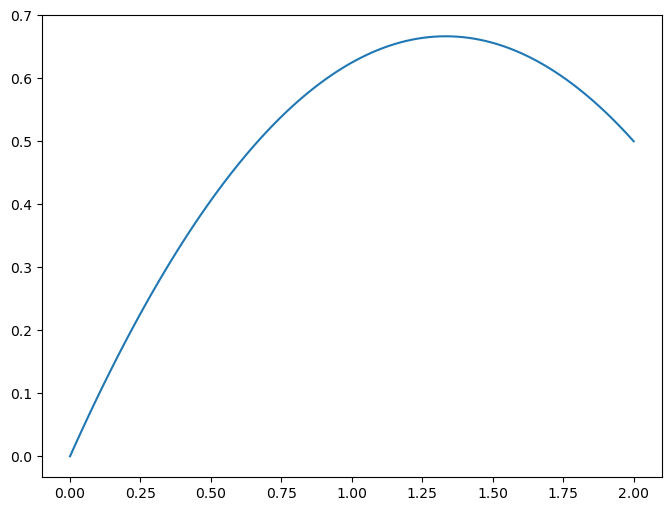

In [68]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2, 100)  
k=-3/8
y = k*x**2+x

plt.figure(figsize=(8, 6))  
plt.plot(x, y)  
plt.show()  